In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import neighbors
from sklearn import model_selection as skms
from sklearn import datasets

iris = datasets.load_iris()
diabetes = datasets.load_diabetes()
digits = datasets.load_digits()

In [5]:
knn = neighbors.KNeighborsClassifier()
print(" ".join(knn.get_params().keys()))

algorithm leaf_size metric metric_params n_jobs n_neighbors p weights


In [6]:
param_grid = {"n_neighbors" : [1,3,5,10,20]}

knn = neighbors.KNeighborsClassifier()

grid_model = skms.GridSearchCV(knn,
                               return_train_score=True,
                               param_grid = param_grid,
                               cv=10)

grid_model.fit(digits.data, digits.target)
print(grid_model)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 3, 5, 10, 20]},
             return_train_score=True)


In [7]:
param_cols = ['param_n_neighbors']
score_cols = ['mean_train_score', 'std_train_score',
              'mean_test_score', 'std_test_score']

df = pd.DataFrame(grid_model.cv_results_).head()

display(df[param_cols + score_cols])

,param_n_neighbors,mean_train_score,std_train_score,mean_test_score,std_test_score
0,1,1.000000,0.000000,0.974963,0.017080
1,3,0.993322,0.000772,0.976633,0.015473
2,5,0.990540,0.000621,0.971074,0.017169
3,10,0.985655,0.001291,0.962163,0.020458
4,20,0.980832,0.001933,0.958824,0.022388


In [8]:
grid_df = pd.DataFrame(grid_model.cv_results_,
                       columns=['param_n_neighbors',
                                'mean_train_score',
                                'mean_test_score'])
grid_df.set_index('param_n_neighbors', inplace=True)
display(grid_df)

,mean_train_score,mean_test_score
param_n_neighbors,,
1,1.000000,0.974963
3,0.993322,0.976633
5,0.990540,0.971074
10,0.985655,0.962163
20,0.980832,0.958824


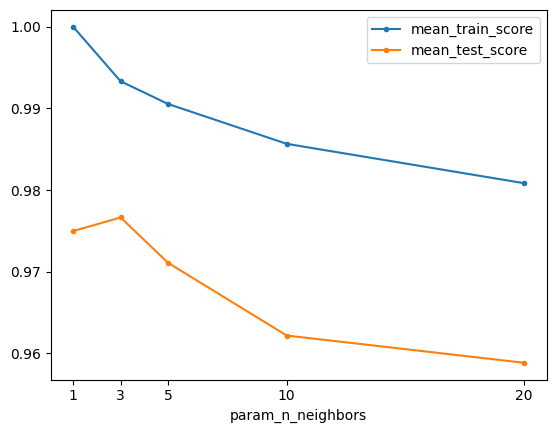

In [9]:
ax = grid_df.plot.line(marker='.')
ax.set_xticks(grid_df.index);

In [10]:
param_grid = {"n_neighbors" : np.arange(1,11),
              "weights"     : ['uniform', 'distance'],
              "p"           : [1,2,4,8,16]}

knn = neighbors.KNeighborsClassifier()
grid_model = skms.GridSearchCV(knn, param_grid = param_grid, cv=10)

In [11]:
%timeit -r1 grid_model.fit(iris.data, iris.target)

2.98 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [12]:
param_df = pd.DataFrame.from_records(grid_model.cv_results_['params'])
param_df['mean_test_score'] = grid_model.cv_results_['mean_test_score']
param_df.sort_values(by=['mean_test_score']).tail()

,n_neighbors,p,weights,mean_test_score
95,10,4,distance,0.98
96,10,8,uniform,0.98
97,10,8,distance,0.98
98,10,16,uniform,0.98
99,10,16,distance,0.98


In [13]:
import scipy.stats as ss
knn = neighbors.KNeighborsClassifier()
param_dists = {"n_neighbors" : ss.randint(1,11),
               "weights"     : ['uniform', 'distance'],
               "p"           : ss.geom(p=.5)}

mod = skms.RandomizedSearchCV(knn,
                              param_distributions = param_dists,
                              cv=10,
                              n_iter=20)

%timeit -r1 mod.fit(iris.data, iris.target)
print(mod.best_score_)

575 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
0.9800000000000001


In [14]:
param_grid = {"n_neighbors" : np.arange(1,11),
              "weights"     : ['uniform', 'distance'],
              "p"           : [1,2,4,8,16]}

knn = neighbors.KNeighborsClassifier()
grid_knn = skms.GridSearchCV(knn,
                             param_grid = param_grid,
                             cv=3)
print(grid_knn)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'p': [1, 2, 4, 8, 16],
                         'weights': ['uniform', 'distance']})


In [15]:
outer_scores = skms.cross_val_score(grid_knn,
                                    iris.data, iris.target,
                                    cv=5)
print(outer_scores)

[0.96666667 1.         0.93333333 0.96666667 1.        ]


In [16]:
from sklearn import preprocessing as skpre
from sklearn import linear_model
from sklearn import pipeline
from sklearn import model_selection as skms

scaler = skpre.StandardScaler()
logreg = linear_model.LogisticRegression()

pipe = pipeline.make_pipeline(scaler, logreg)
print(skms.cross_val_score(pipe, iris.data, iris.target, cv=10))

[1.         0.93333333 1.         1.         0.93333333 0.93333333
 0.8        1.         1.         1.        ]


In [45]:
def extract_name(obj):
    return str(logreg.__class__).split('.')[-1][:-2].lower()

print(logreg.__class__)
print(extract_name(logreg))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
logisticregression


In [18]:
pipe.named_steps.keys()

dict_keys(['standardscaler', 'logisticregression'])

In [19]:
pipe = pipeline.Pipeline(steps=[('scaler', scaler),
                                ('knn', knn)])

cv_scores = skms.cross_val_score(pipe, iris.data, iris.target,
                                 cv=10,
                                 n_jobs=-1) # all CPUs
print(pipe.named_steps.keys())
print(cv_scores)

dict_keys(['scaler', 'knn'])
[1.         0.93333333 1.         0.93333333 0.86666667 0.93333333
 0.86666667 1.         1.         1.        ]


In [20]:
from sklearn.base import TransformerMixin
class Median_Big_Small(TransformerMixin):
    def __init__(self):
        pass
    def fit(self, ftrs, tgt=None):
        self.medians = np.median(ftrs)
        return self
    def transform(self, ftrs, tgt=None):
        return ftrs > self.medians

In [44]:
scaler = skpre.StandardScaler()
quad_inters = skpre.PolynomialFeatures(degree=2,
                                       interaction_only=True,
                                       include_bias=False)
median_big_small = Median_Big_Small()
knn = neighbors.KNeighborsClassifier()

pipe = pipeline.Pipeline(steps=[('scaler', scaler),
                                ('inter',  quad_inters),
                                ('mbs',    median_big_small),
                                ('knn',    knn)])

cv_scores = skms.cross_val_score(pipe, iris.data, iris.target, cv=10)

print(cv_scores)

[0.6        0.66666667 0.8        0.73333333 0.8        0.66666667
 0.66666667 0.66666667 0.8        0.8       ]


In [22]:
scaler = skpre.StandardScaler()
poly   = skpre.PolynomialFeatures()
lasso  = linear_model.Lasso(selection='random', tol=.01)
pipe = pipeline.make_pipeline(scaler,
                              poly,
                              lasso)

In [23]:
param_grid = {"polynomialfeatures__degree" : np.arange(2,6),
              "lasso__alpha" : np.logspace(1,6,6,base=2)}

from pprint import pprint as pp
pp(param_grid)

{'lasso__alpha': array([ 2.,  4.,  8., 16., 32., 64.]),
 'polynomialfeatures__degree': array([2, 3, 4, 5])}


In [25]:
mod = skms.GridSearchCV(pipe, param_grid, n_jobs=-1)
mod.fit(diabetes.data, diabetes.target)

GridSearchCV(estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('lasso',
                                        Lasso(selection='random', tol=0.01))]),
             n_jobs=-1,
             param_grid={'lasso__alpha': array([ 2.,  4.,  8., 16., 32., 64.]),
                         'polynomialfeatures__degree': array([2, 3, 4, 5])})

In [26]:
import textwrap
for name, step in mod.best_estimator_.named_steps.items():
    print("Step:", name)
    print(textwrap.indent(textwrap.fill(str(step), 50), " " * 6))

Step: standardscaler
      StandardScaler()
Step: polynomialfeatures
      PolynomialFeatures(degree=np.int64(2))
Step: lasso
      Lasso(alpha=np.float64(4.0), selection='random',
      tol=0.01)


In [27]:
pp(mod.best_params_)

{'lasso__alpha': np.float64(4.0), 'polynomialfeatures__degree': np.int64(2)}
